## Import libraries


In [1]:
import sys
from pathlib import Path
import warnings

sys.path.insert(0, "../scripts")
from clock_utils import (
    build_cluster_X,
    build_thompson_cluster_features,
    build_thompson_cpg_features,
    nested_cv,
    plot_age_clock,
)
from segmentation_utils import cluster_chroms, cluster_summary
from cluster_aggregation_utils import (
    # build_cluster_corr_X,
    build_cluster_binned_X,
    # build_cluster_cov_X,
 )

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, root_mean_squared_error


ModuleNotFoundError: No module named 'matplotlib'

## Output Directories & Configuration

In [ ]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output, disable if you want to see them

output_dir = Path("../outputs/03_bin_segmentation")
plots_dir = output_dir / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

colors = dict(
    cpg="steelblue",
    dbs="tomato",
    hdbscan="#006d2c",
    hdbscan_5="#74c476",
    hdbscan_10="#31a354",
    optics="mediumpurple",
)
labels_map = dict(
    cpg="CpG",
    dbs="DBSCAN",
    hdbscan="HDBSCAN mcs=20",
    hdbscan_5="HDBSCAN mcs=5",
    hdbscan_10="HDBSCAN mcs=10",
    optics="OPTICS",
)

# Training and testing Petkovich cluster-based and CpG-based clocks on the Petkovich dataset

## Preprocessing of the data

Preprocessing of both Petkovich and Thompson data was performed by Evgeniy Efimov. During the preprocesing step, all the methylation sites that had coverage <= 5 reads were handled as NaN.

## Load data

For some reason, `GSE80672_metlevs_processed.parquet.gz` does not contain some of the samples from the original GEO ('GSM2132821', 'GSM2132831', 'GSM2132846', 'GSM2132859', 'GSM2132894', 'GSM2132941', 'GSM2132943', 'GSM2132951', 'GSM2132959')

In [ ]:
# Read Petkovich et al. (2017) methylation levels and metadata
parquet_cols = set(
    pq.read_schema(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz"
    ).names
)

petkovich_meta = (
    pd.read_csv(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metadata_cleaned.csv"
    )
    .query("ID.str.match(r'^M(?!I)')")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in petkovich_meta["GSE"] if gse in parquet_cols]

petkovich_meta = petkovich_meta[petkovich_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
petkovich = pd.read_parquet(
    "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz",
    columns=valid_ids,
)


## Use various density-based methods to cluster methylation sites

### Parse site coordinates

In [ ]:
# Divide site index into chromosome and position
site_coords = pd.DataFrame(
    {
        "chrom": petkovich.index.str.rsplit("_", n=1).str[0],
        "pos": petkovich.index.str.rsplit("_", n=1).str[1].astype(int),
    },
    index=petkovich.index,
)

# Pre-compute chromosome groups once — reused for all three clustering methods
groups = list(site_coords.groupby("chrom"))

# y is defined early so HP search cells can use it without running feature matrices first
y = petkovich_meta.set_index("GSE")["Age"].loc[petkovich.columns].astype(float)

### Cluster CpS using DBSCAN

I did not search for hyperparameters for DBSCAN, since it was already performed by Simpson et. el. (2023)


DBSCAN eps=1000
Clusters:          57,065
Noise CpGs:       172,402  (14.5%)
Clustered CpGs: 1,020,649  (85.5%)

CpGs per cluster:
  mean:       17.9
  median:      9.0
  std:        24.0
  min:           5
  p25:           6
  p75:          17
  p90:          45
  p99:         122
  max:         589


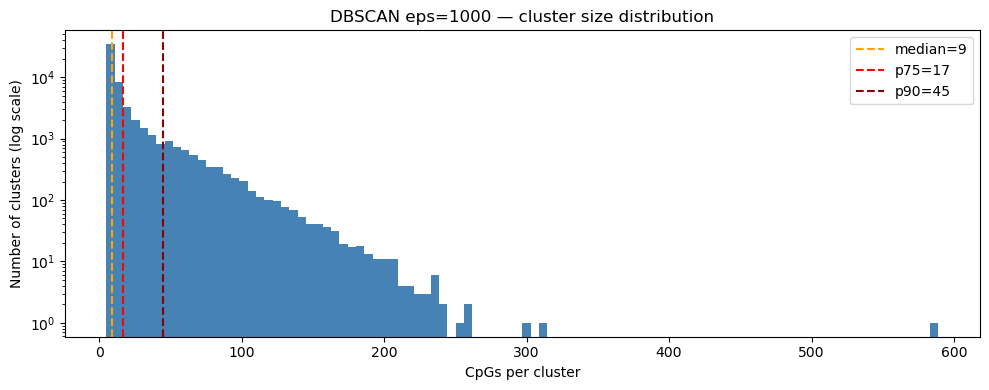

In [ ]:
# eps = maximum distance in bp between neighboring CpGs to be in the same cluster (as in the original paper)
# min_samples = the number of samples (or total weight) in a neighborhood for a point to be considered as a core point (as in the original paper)

site_coords["cluster_dbs"] = cluster_chroms(
    groups, site_coords.index, DBSCAN, dict(eps=1000, min_samples=5)
)
cluster_summary(site_coords["cluster_dbs"], name="DBSCAN eps=1000", plot_dir=plots_dir)

### Cluster CpS using HDBSCAN with different hyperparameters and perform nested cross-validation 

In [ ]:
agg_output_dir = output_dir / "aggregated_features"
agg_output_dir.mkdir(parents=True, exist_ok=True)

labels = site_coords["cluster_dbs"]
in_cluster = labels[labels != -1]
clustered_petkovich = petkovich.loc[in_cluster.index]
grouped_petkovich = clustered_petkovich.groupby(in_cluster, sort=False)

def _finalize_train_features(X):
    return X.fillna(X.mean())

def _build_grouped_feature(stat):
    X = getattr(grouped_petkovich, stat)().T
    return _finalize_train_features(X)

aggregation_builders = {
    "mean": lambda: _build_grouped_feature("mean"),
    "median": lambda: _build_grouped_feature("median"),
    # "corr_spearman": lambda: build_cluster_corr_X(
    #     methylation_matrix=petkovich,
    #     site_coords=site_coords,
    #     cluster_col="cluster_dbs",
    #     pos_col="pos",
    #     method="spearman",
    #     fillna="cluster_mean",
    # ),
    # "cov": lambda: build_cluster_cov_X(
    #     methylation_matrix=petkovich,
    #     site_coords=site_coords,
    #     cluster_col="cluster_dbs",
    #     pos_col="pos",
    #     fillna="feature_mean",
    # ),
    "binned_mean_n_bins": lambda: build_cluster_binned_X(
        methylation_matrix=petkovich,
        site_coords=site_coords,
        cluster_col="cluster_dbs",
        pos_col="pos",
        bin_mode="n_bins",
        n_bins=5,
        bin_agg="mean",
        fillna="feature_mean",
    ),
    "binned_mean_sites_per_bin": lambda: build_cluster_binned_X(
        methylation_matrix=petkovich,
        site_coords=site_coords,
        cluster_col="cluster_dbs",
        pos_col="pos",
        bin_mode="sites_per_bin",
        sites_per_bin=5,
        bin_agg="mean",
        fillna="feature_mean",
    ),
}

aggregated_features = {}
for name, build_features in aggregation_builders.items():
    X = build_features()
    aggregated_features[name] = X

    output_path = agg_output_dir / f"petkovich_cluster_dbs_{name}.pkl"
    with open(output_path, "wb") as f:
        pickle.dump(X, f)

    n_nans = int(X.isna().sum().sum())
    print(
        f"{name:14s} -> shape={X.shape}, NaN count={n_nans}, saved: {output_path.name}"
    )

## Nested cross-validation — internal testing (Petkovich)

Outer 5 folds evaluate R² and RMSE; inner 5 folds in LassoCV select alpha.

### Build feature matrices

In [ ]:
petkovich_clean = petkovich.dropna(axis=0, how="any")
X_cpg = petkovich_clean.T
X_dbs = build_cluster_X(petkovich, site_coords, "cluster_dbs")

print(f"CpG features: {X_cpg.shape[1]}, samples: {len(y)}")
#print(f"DBSCAN: {X_dbs.shape[1]}, HDBSCAN mcs=5: {X_hdbscan_5.shape[1]}, mcs=10: {X_hdbscan_10.shape[1]}, mcs={best_mcs}: {X_hdbscan.shape[1]}")

## Train the final model that will be used for testing on external datasets
As the last step, we will train the final model on 100% of Petkovich data.

In [ ]:
final_models = {}
for name, X in [
    ("cpg", X_cpg),
    #("dbs", X_dbs),
    ("dbs_mean", aggregated_features["mean"]),
    ("dbs_median", aggregated_features["median"]),
    # ("dbs_corr_spearman", aggregated_features["corr_spearman"]),
    # ("dbs_cov", aggregated_features["cov"]),
    ("dbs_binned_n_bins", aggregated_features["binned_mean_n_bins"]),
    ("dbs_binned_sites_per_bin", aggregated_features["binned_mean_sites_per_bin"]),
]:
    print(name)
    model = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42).fit(X, y)
    final_models[name] = model
    print(f"{name:18s}: alpha={model.alpha_:.4f}, features={(model.coef_ != 0).sum()}")
    with open(f"{output_dir}/petkovich_{name}_full_model.pkl", "wb") as f:
        pickle.dump(model, f)


# Testing Petkovich cluster-based and CpG-based clocks on the external Thompson dataset

## Load the data
Since we have trained our models on the blood methylation data from the Petkovich dataset, we will leverage only the blood methylation data from the Thompson dataset for testing. 

In [ ]:
# Read Thompson et al. (2018) methylation levels and metadata (blood samples only)
parquet_cols = set(
    pq.read_schema(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz"
    ).names
)

thompson_meta = (
    pd.read_csv(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metadata_cleaned.csv"
    )
    .query("Tissue == 'Blood'")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in thompson_meta["GSE"] if gse in parquet_cols]

thompson_meta = thompson_meta[thompson_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
thompson = pd.read_parquet(
    "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz",
    columns=valid_ids,
).T

In [ ]:
thompson_sites = thompson.T

def _finalize_external_features(X_external, X_train):
    X_external = X_external.reindex(columns=X_train.columns)
    X_external = X_external.fillna(X_external.mean())
    X_external = X_external.fillna(X_train.mean())
    return X_external.to_numpy(dtype="float64")

clustered_dbs = site_coords.loc[site_coords["cluster_dbs"] != -1, "cluster_dbs"]
thompson_clustered_sites = clustered_dbs.index.intersection(thompson_sites.index)
thompson_cluster_labels = clustered_dbs.loc[thompson_clustered_sites]
thompson_cluster_matrix = thompson_sites.loc[thompson_clustered_sites]

X_thompson = {
    "cpg": build_thompson_cpg_features(thompson, X_cpg),
    #"dbs": build_thompson_cluster_features(thompson, site_coords, "cluster_dbs", X_dbs),
    "dbs_mean": _finalize_external_features(
        thompson_cluster_matrix.groupby(thompson_cluster_labels).mean().T,
        aggregated_features["mean"],
    ),
    "dbs_median": _finalize_external_features(
        thompson_cluster_matrix.groupby(thompson_cluster_labels).median().T,
        aggregated_features["median"],
    ),
    # "dbs_corr_spearman": _finalize_external_features(
    #     build_cluster_corr_X(
    #         methylation_matrix=thompson_sites,
    #         site_coords=site_coords,
    #         cluster_col="cluster_dbs",
    #         pos_col="pos",
    #         method="spearman",
    #         fillna="cluster_mean",
    #     ),
    #     aggregated_features["corr_spearman"],
    # ),
    # "dbs_cov": _finalize_external_features(
    #     build_cluster_cov_X(
    #         methylation_matrix=thompson_sites,
    #         site_coords=site_coords,
    #         cluster_col="cluster_dbs",
    #         pos_col="pos",
    #         fillna="feature_mean",
    #     ),
    #     aggregated_features["cov"],
    # ),
    "dbs_binned_n_bins": _finalize_external_features(
        build_cluster_binned_X(
            methylation_matrix=thompson_sites,
            site_coords=site_coords,
            cluster_col="cluster_dbs",
            pos_col="pos",
            bin_mode="n_bins",
            n_bins=5,
            bin_agg="mean",
            fillna="feature_mean",
        ),
        aggregated_features["binned_mean_n_bins"],
    ),
    "dbs_binned_sites_per_bin": _finalize_external_features(
        build_cluster_binned_X(
            methylation_matrix=thompson_sites,
            site_coords=site_coords,
            cluster_col="cluster_dbs",
            pos_col="pos",
            bin_mode="sites_per_bin",
            sites_per_bin=5,
            bin_agg="mean",
            fillna="feature_mean",
        ),
        aggregated_features["binned_mean_sites_per_bin"],
    ),
}

y_thompson = thompson_meta["Age"]

In [ ]:
preds_ext_all = []
for name in ["cpg", "dbs_mean", "dbs_median", "dbs_binned_n_bins", "dbs_binned_sites_per_bin"]:
    pred = final_models[name].predict(X_thompson[name])
    r2 = r2_score(y_thompson, pred)
    rmse = root_mean_squared_error(y_thompson, pred)
    preds_ext_all.append(
        (
            pred,
            f"{labels_map.get(name, name)}\nR²: {r2:.3f}, RMSE: {rmse:.2f}",
            colors.get(name, "steelblue"),
        )
    )

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, style in zip(axes, ["lines", "scatter"]):
    plot_age_clock(
        preds_ext_all,
        y_thompson,
        "External Validation (Thompson, blood): All Methods",
        style=style,
        ax=ax,
    )

    for line in ax.lines:
        label = line.get_label()
        if "Baseline" in label:
            line.set_linewidth(2.0)
        else:
            line.set_linewidth(3.0)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(12)
        legend.get_frame().set_linewidth(1.5)

    ax.set_title(ax.get_title(), fontsize=18)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()

fig.savefig(
    plots_dir / "thompson_validation_all_methods.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    plots_dir / "thompson_validation_all_methods.svg",
    bbox_inches="tight",
)

plt.show()